# Online Retail Customer Analysis

## Goal
The goal of this project is to clean a real retail transaction dataset, analyze customer purchase behavior, and segment customers into groups based on their shopping patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [7]:
%pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

file_path = "Online_Retail.xlsx"
df = pd.read_excel(file_path)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum().sort_values(ascending=False)

CustomerID     135080
Description      1454
StockCode           0
InvoiceNo           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

## Initial observations
- Some rows may have missing customer IDs.
- There may be cancellations.
- Quantities or prices may include unusual values.
- We need to clean the data before customer analysis.

In [9]:
df_clean = df.copy()

In [10]:
df_clean = df_clean.dropna(subset=["CustomerID"]).copy()

In [11]:
df_clean["InvoiceNo"] = df_clean["InvoiceNo"].astype(str)
df_clean = df_clean[~df_clean["InvoiceNo"].str.startswith("C")].copy()

In [12]:
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)].copy()

In [13]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

In [14]:
df_clean["Description"] = df_clean["Description"].astype(str).str.strip()

In [15]:
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

In [16]:
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

In [17]:
df_clean = df_clean.drop_duplicates().copy()

In [18]:
df_clean.shape

(392692, 9)

In [19]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Performed the following cleaning steps:
- Dropped rows without a customer ID
- Removed cancellations
- Kept only positive quantities and positive prices
- Converted dates properly
- Cleaned text columns a little
- Converted customer ID to an integer
- Created a total transaction value column
- Removed exact duplicate rows

In [27]:
country_sales = (
    df_clean.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

country_sales.head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

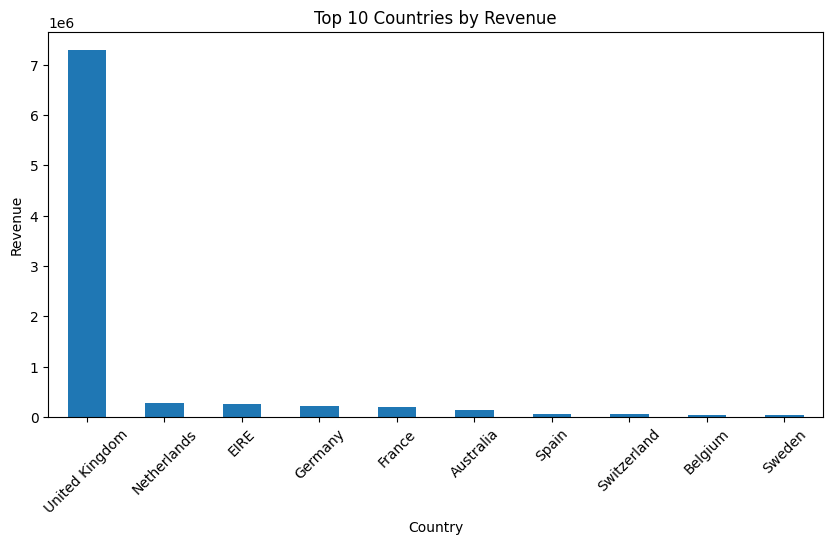

In [28]:
country_sales.head(10).plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.show()

In [31]:
product_sales = (
    df_clean.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalPrice, dtype: float64

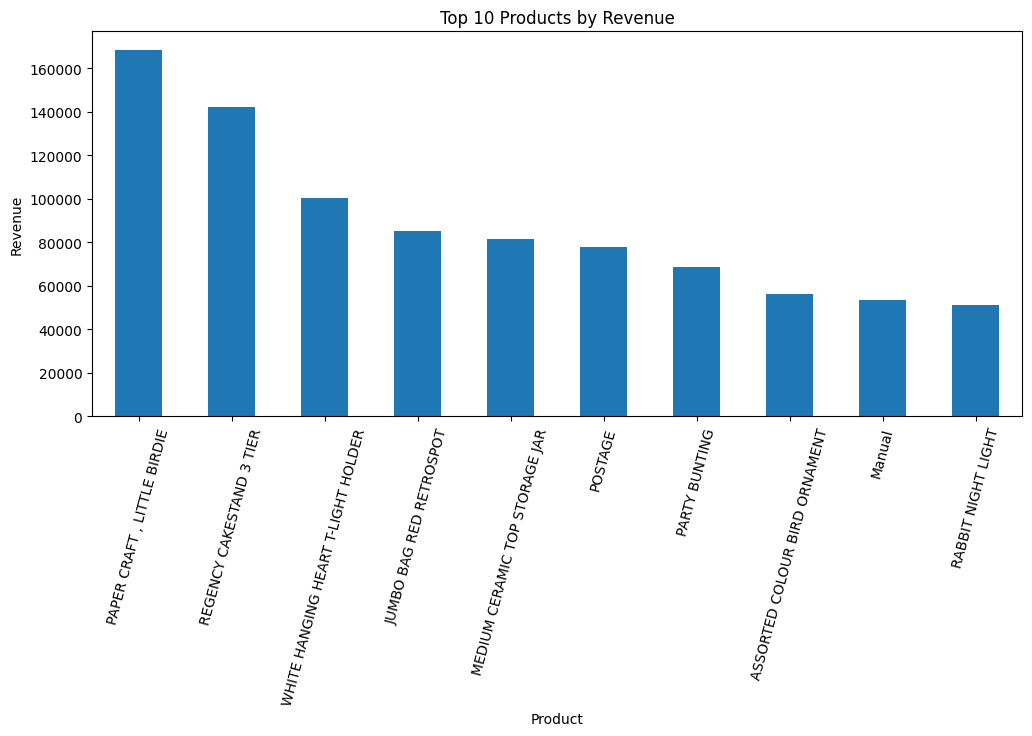

In [32]:
product_sales.head(10).plot(kind="bar", figsize=(12, 5))
plt.title("Top 10 Products by Revenue")
plt.ylabel("Revenue")
plt.xlabel("Product")
plt.xticks(rotation=75)
plt.show()

In [34]:
monthly_sales = (
    df_clean.set_index("InvoiceDate")
    .resample("ME")["TotalPrice"]
    .sum()
)

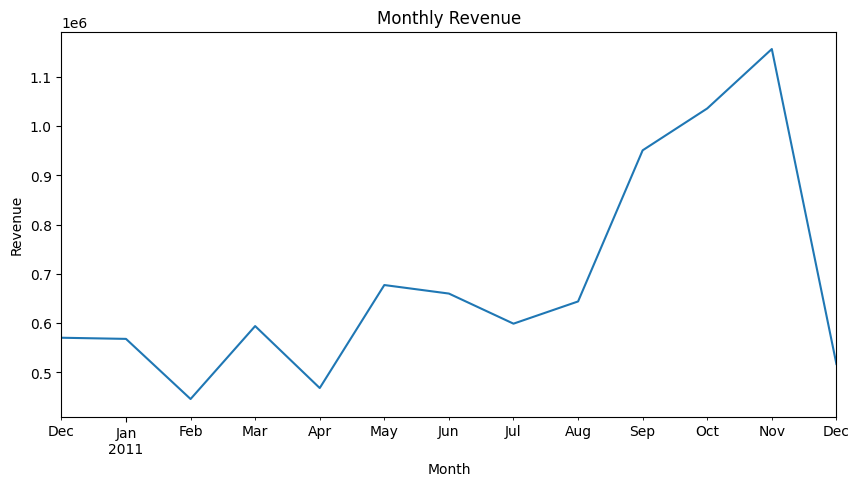

In [35]:
monthly_sales.plot(figsize=(10, 5))
plt.title("Monthly Revenue")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.show()

In [37]:
customers_by_country = (
    df_clean.groupby("Country")["CustomerID"]
    .nunique()
    .sort_values(ascending=False)
)

customers_by_country.head(10)

Country
United Kingdom    3920
Germany             94
France              87
Spain               30
Belgium             25
Switzerland         21
Portugal            19
Italy               14
Finland             12
Austria             11
Name: CustomerID, dtype: int64

- The purpose of this was that revenue alone can be misleading. A country might have high revenue because of a few large customers. But the latest analysis shows that the UK actually has more number of customers.

## Right now, each row is a transaction line. But for customer analysis, you need one row per customer.
- The classic way to do this is with RFM-style features:
- Recency = how recently the customer purchased
- Frequency = how often the customer purchased
- Monetary = how much the customer spent.

## First, we will choose a snapshot date. Usually, this is one day after the last transaction date.-

In [38]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [39]:
rfm = (
    df_clean.groupby("CustomerID")
    .agg({
        "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
        "InvoiceNo": "nunique",
        "TotalPrice": "sum"
    })
    .reset_index()
)

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [40]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


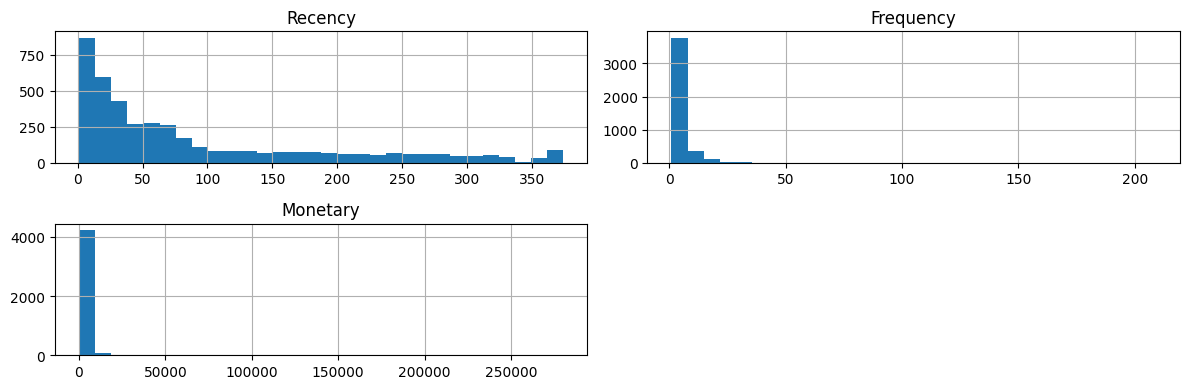

In [41]:
rfm[["Recency", "Frequency", "Monetary"]].hist(figsize=(12, 4), bins=30)
plt.tight_layout()
plt.show()

In [42]:
rfm_log = rfm.copy()
rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

In [43]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_log[["Recency", "Frequency", "Monetary"]])

In [44]:
inertias = []
k_values = range(2, 9)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    model.fit(X_scaled)
    inertias.append(model.inertia_)

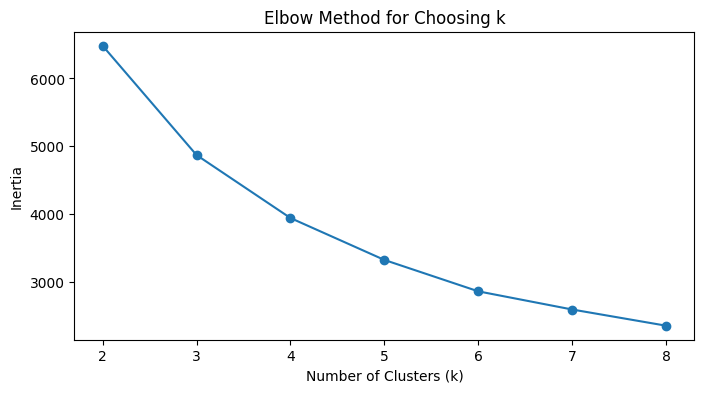

In [45]:
plt.figure(figsize=(8, 4))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow Method for Choosing k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [46]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

In [47]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,2
1,12347,2,7,4310.00,1
2,12348,75,4,1797.24,2
3,12349,19,1,1757.55,0
4,12350,310,1,334.40,3


In [48]:
cluster_summary = (
    rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
    .mean()
    .round(2)
)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,20.05,2.01,510.28
1,11.74,13.78,8107.55
2,66.72,4.17,1819.25
3,186.73,1.34,353.81


In [49]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0     856
1     707
2    1185
3    1590
Name: count, dtype: int64

In [51]:
cluster_name_map = {
    0: "Regular Customers",
    1: "Best Customers",
    2: "At-Risk Customers",
    3: "New/Occasional Customers"
}

rfm["ClusterName"] = rfm["Cluster"].map(cluster_name_map)

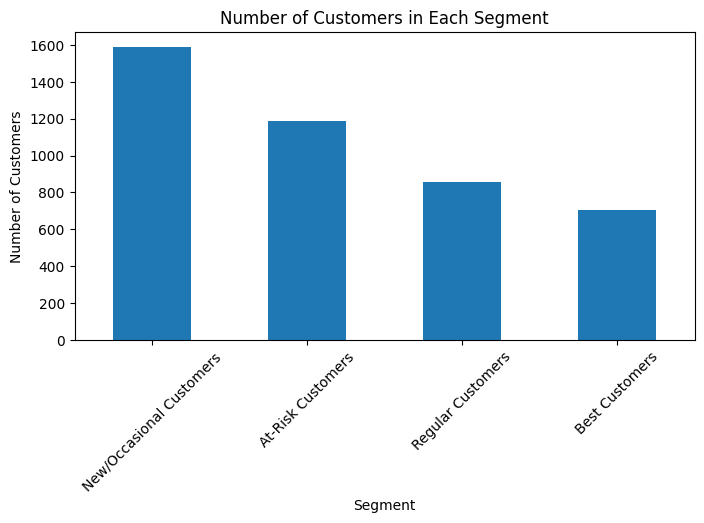

In [52]:
rfm["ClusterName"].value_counts().plot(kind="bar", figsize=(8, 4))
plt.title("Number of Customers in Each Segment")
plt.ylabel("Number of Customers")
plt.xlabel("Segment")
plt.xticks(rotation=45)
plt.show()

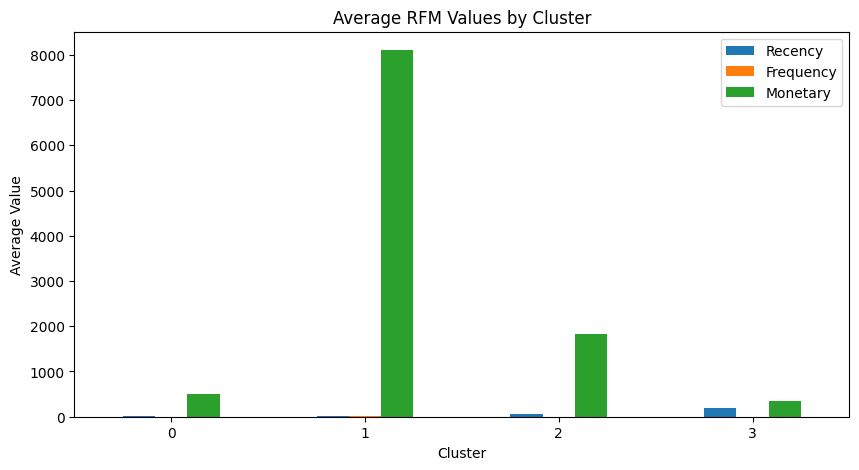

In [53]:
cluster_summary.plot(kind="bar", figsize=(10, 5))
plt.title("Average RFM Values by Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

## Findings
- The United Kingdom appears to contribute the most revenue.
- A small number of products contribute a large share of sales.
- Customer behaviour is highly uneven: some customers buy frequently and spend a lot, while many buy rarely.
- The clustering suggests there are distinct customer groups, such as best customers, loyal customers, inactive customers, and occasional buyers.

In [55]:
df_clean.to_csv("cleaned_online_retail.csv", index=False)

In [56]:
rfm.to_csv("customer_segments.csv", index=False)